In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from process_data import extract_data, n_extract_data
pv.start_xvfb()
pv.set_jupyter_backend('static')
from scipy.spatial.transform import Rotation
import sys
sys.path.append("/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/utils")
from plotting import *
from utils import * 
total_points = 512
lines = 10_000
compute_bc_mask=True 
compute_spatial_features=True
from IPython.display import clear_output

In [2]:

db_path1 = '/local/scratch/groves/jax-forgeRL/jax-forge/data/tianhong_data/noisy_cogging.db'
db_path2 = '/local/scratch/groves/jax-forgeRL/jax-forge/data/tianhong_data/RL_random_cogging.db'
data1 = n_extract_data(db_path1, total_points, lines, 
                      compute_bc_mask=compute_bc_mask, compute_spatial_features=compute_spatial_features, n_workers=64)
data2 = n_extract_data(db_path2, total_points, lines, compute_bc_mask=compute_bc_mask, compute_spatial_features=compute_spatial_features, n_workers=64)

data = {}
for key in data1.keys():
    if key in ['series_lengths', 'series_ids', 'meshes', 'meshes_tp1']:
        data[key] = data1[key] + data2[key]
    else:
        data[key] = np.vstack((data1[key], data2[key]))


Processing 137 series using 64 workers...


Processing series: 100%|██████████| 137/137 [00:20<00:00,  6.70it/s]


Processing 67 series using 64 workers...


Processing series: 100%|██████████| 67/67 [00:22<00:00,  3.02it/s]


In [12]:
print(data['series_ids'][2])
print(data['series_lengths'])
#'72f102a6-9d91-490e-8a81-0c64ef0b9945' = idx of 1
print (data['series_lengths'][2])

d49fd4ab-711f-483d-a18c-8c63374ae643
[11, 53, 10, 51, 83, 79, 137, 7, 49, 71, 91, 125, 9, 55, 71, 107, 143, 9, 65, 65, 87, 167, 12, 53, 71, 87, 149, 11, 55, 68, 103, 137, 11, 47, 65, 87, 167, 10, 51, 62, 83, 113, 12, 59, 74, 91, 149, 8, 45, 80, 91, 143, 12, 49, 77, 99, 149, 9, 45, 68, 91, 143, 9, 9, 53, 83, 79, 137, 9, 47, 71, 83, 125, 9, 49, 77, 103, 137, 8, 45, 71, 95, 131, 11, 53, 80, 99, 161, 11, 59, 80, 83, 137, 11, 57, 83, 99, 131, 9, 51, 83, 91, 137, 8, 37, 68, 75, 125, 9, 53, 71, 99, 143, 12, 69, 68, 95, 137, 8, 55, 71, 83, 155, 11, 59, 68, 95, 179, 10, 59, 68, 99, 143, 8, 41, 80, 87, 137, 8, 63, 74, 91, 155, 12, 53, 68, 83, 179, 12, 57, 68, 87, 149, 10, 57, 59, 79, 143, 10, 43, 77, 99, 149, 11, 49, 74, 87, 137, 10, 45, 83, 95, 137, 11, 49, 77, 75, 125, 9, 51, 62, 95, 161, 5, 9, 57, 65, 95, 167, 8, 49, 62, 79, 155, 9, 47, 59, 87, 131, 12, 67, 71, 83, 131, 10, 49, 77, 75, 149, 11, 57, 68, 107, 143, 9, 45, 74, 87, 131, 10, 39, 68, 91, 161, 11, 47, 71, 95, 131, 10, 55, 77, 91, 143

55 64


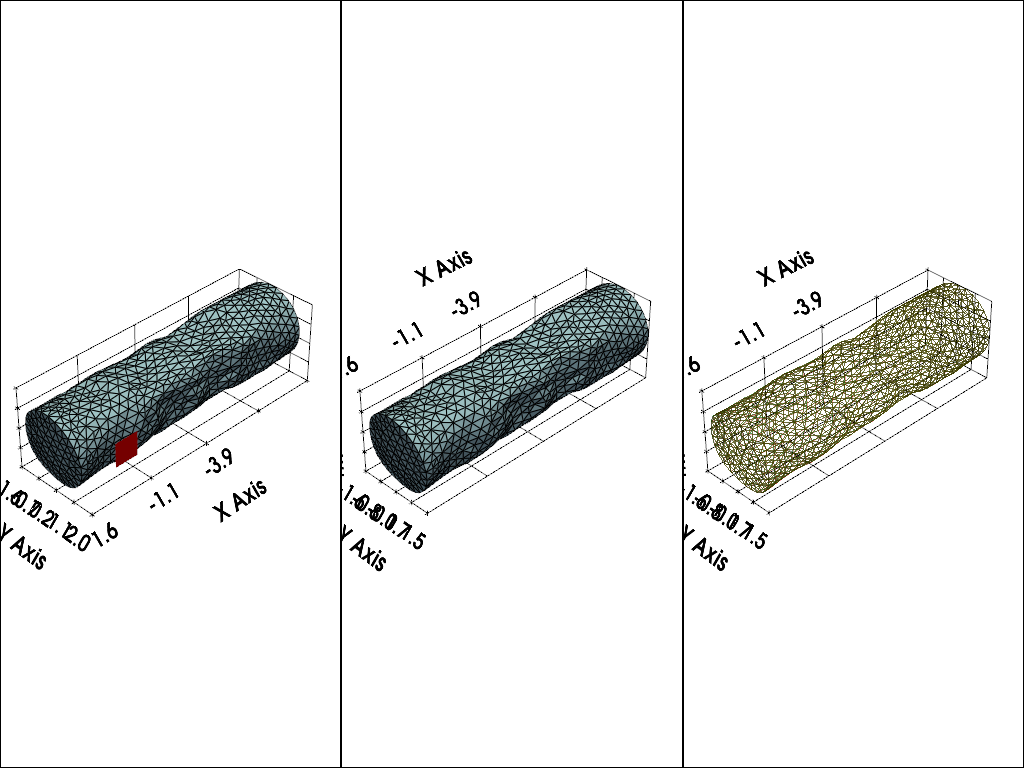

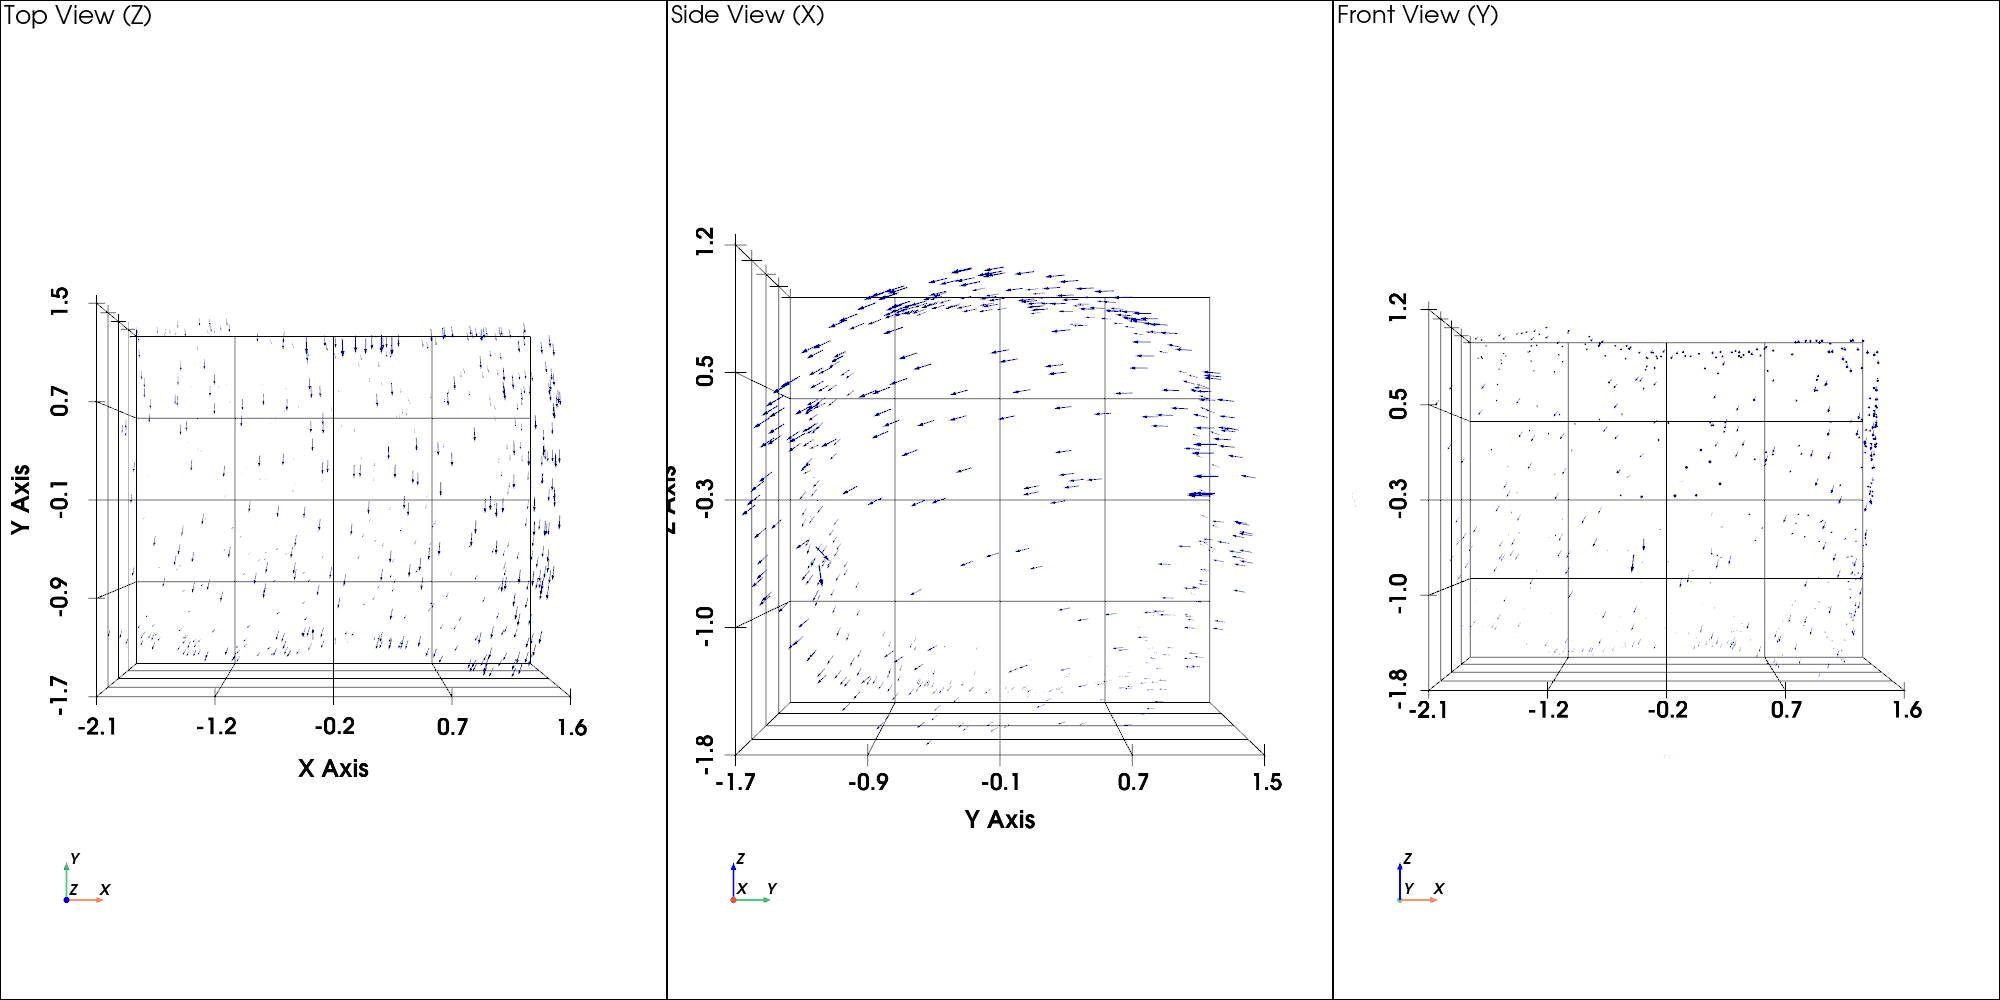

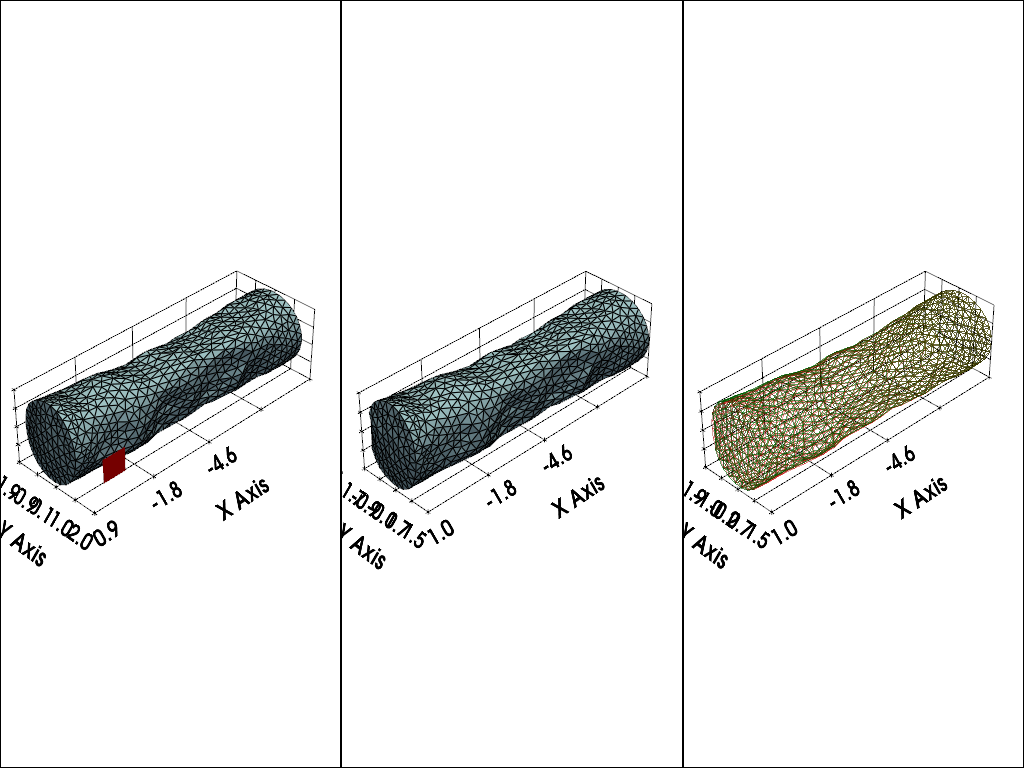

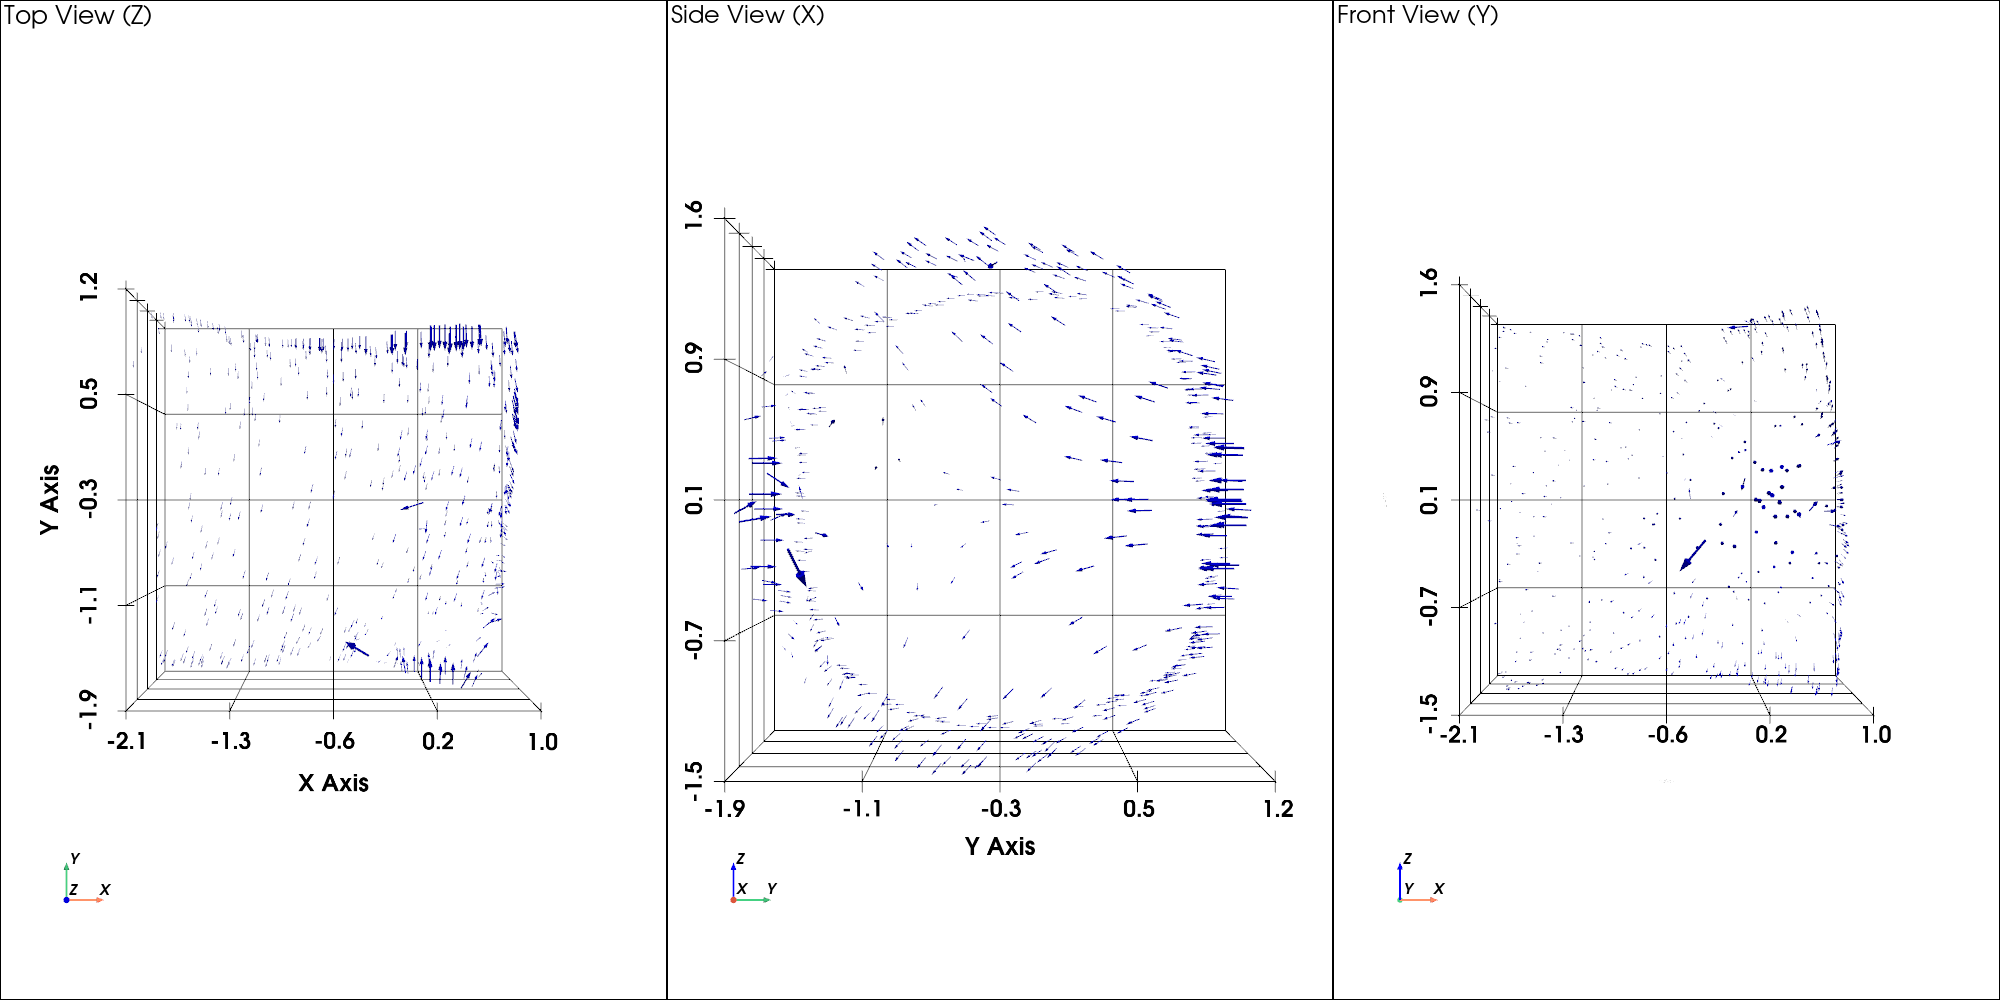

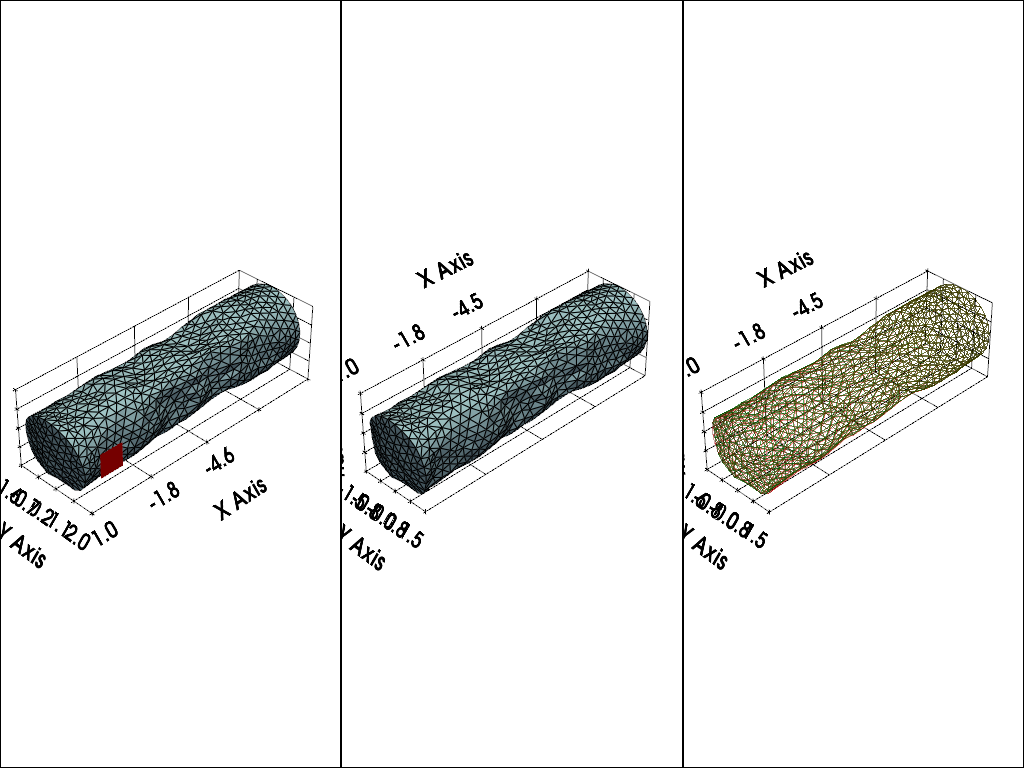

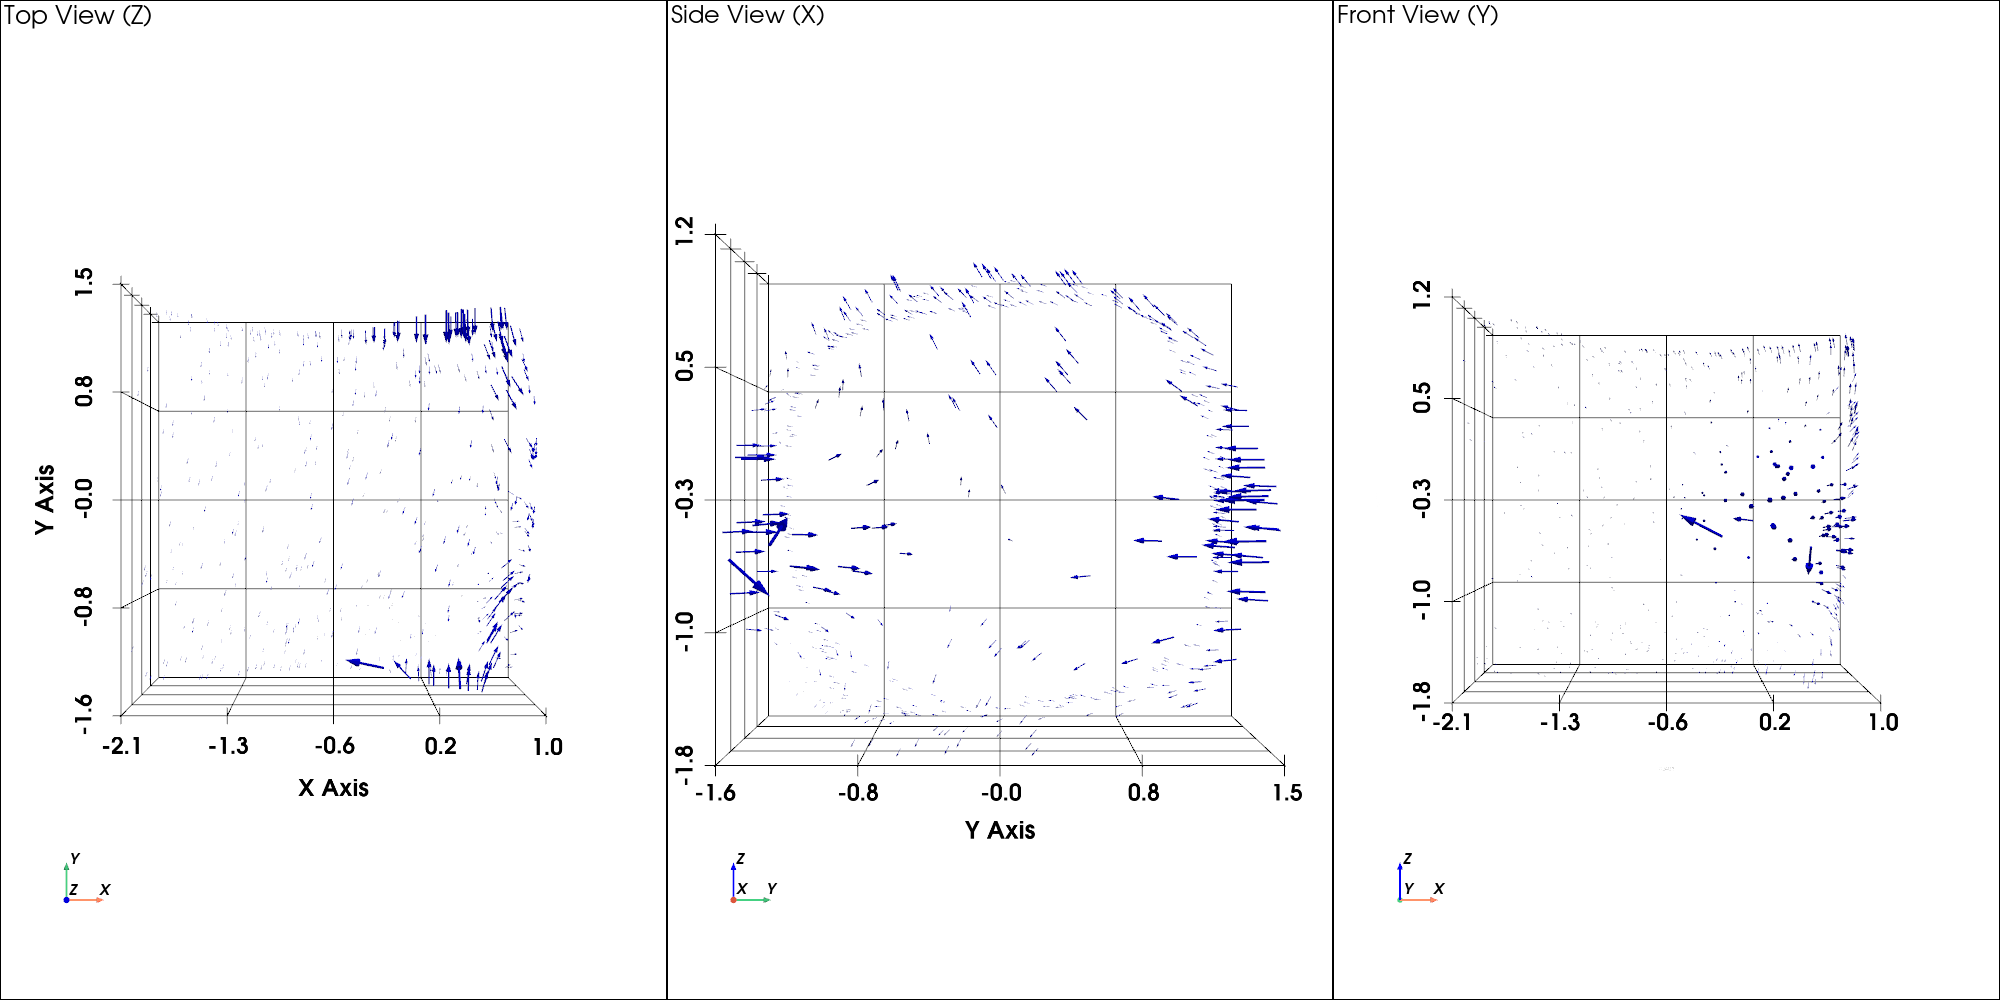

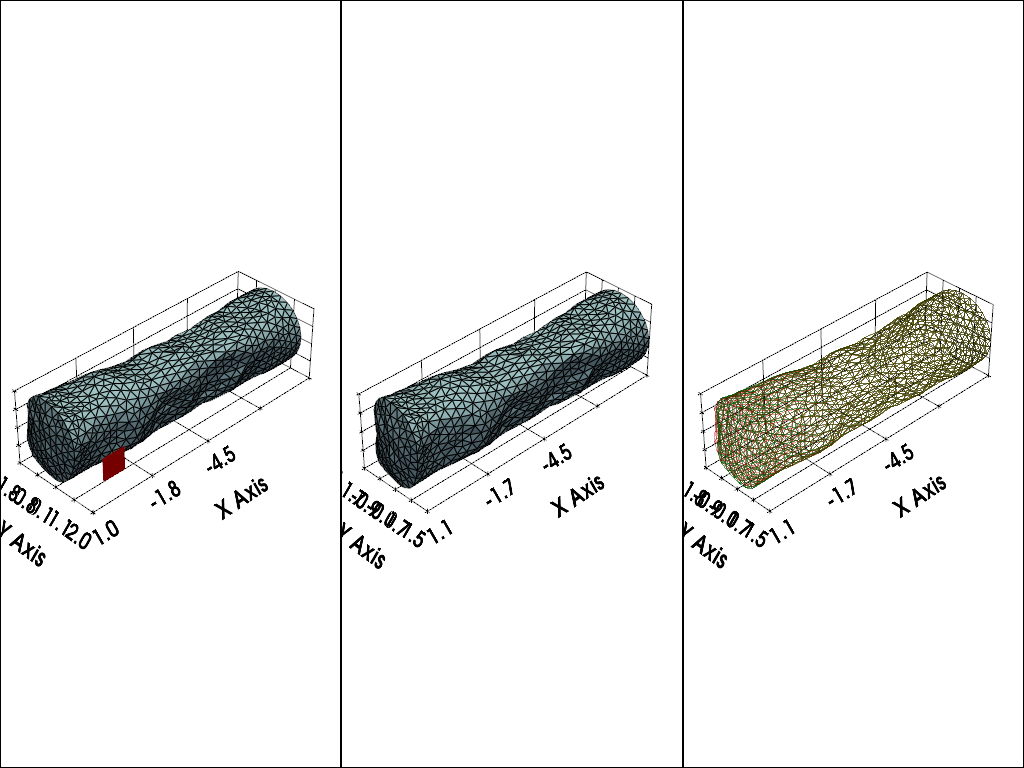

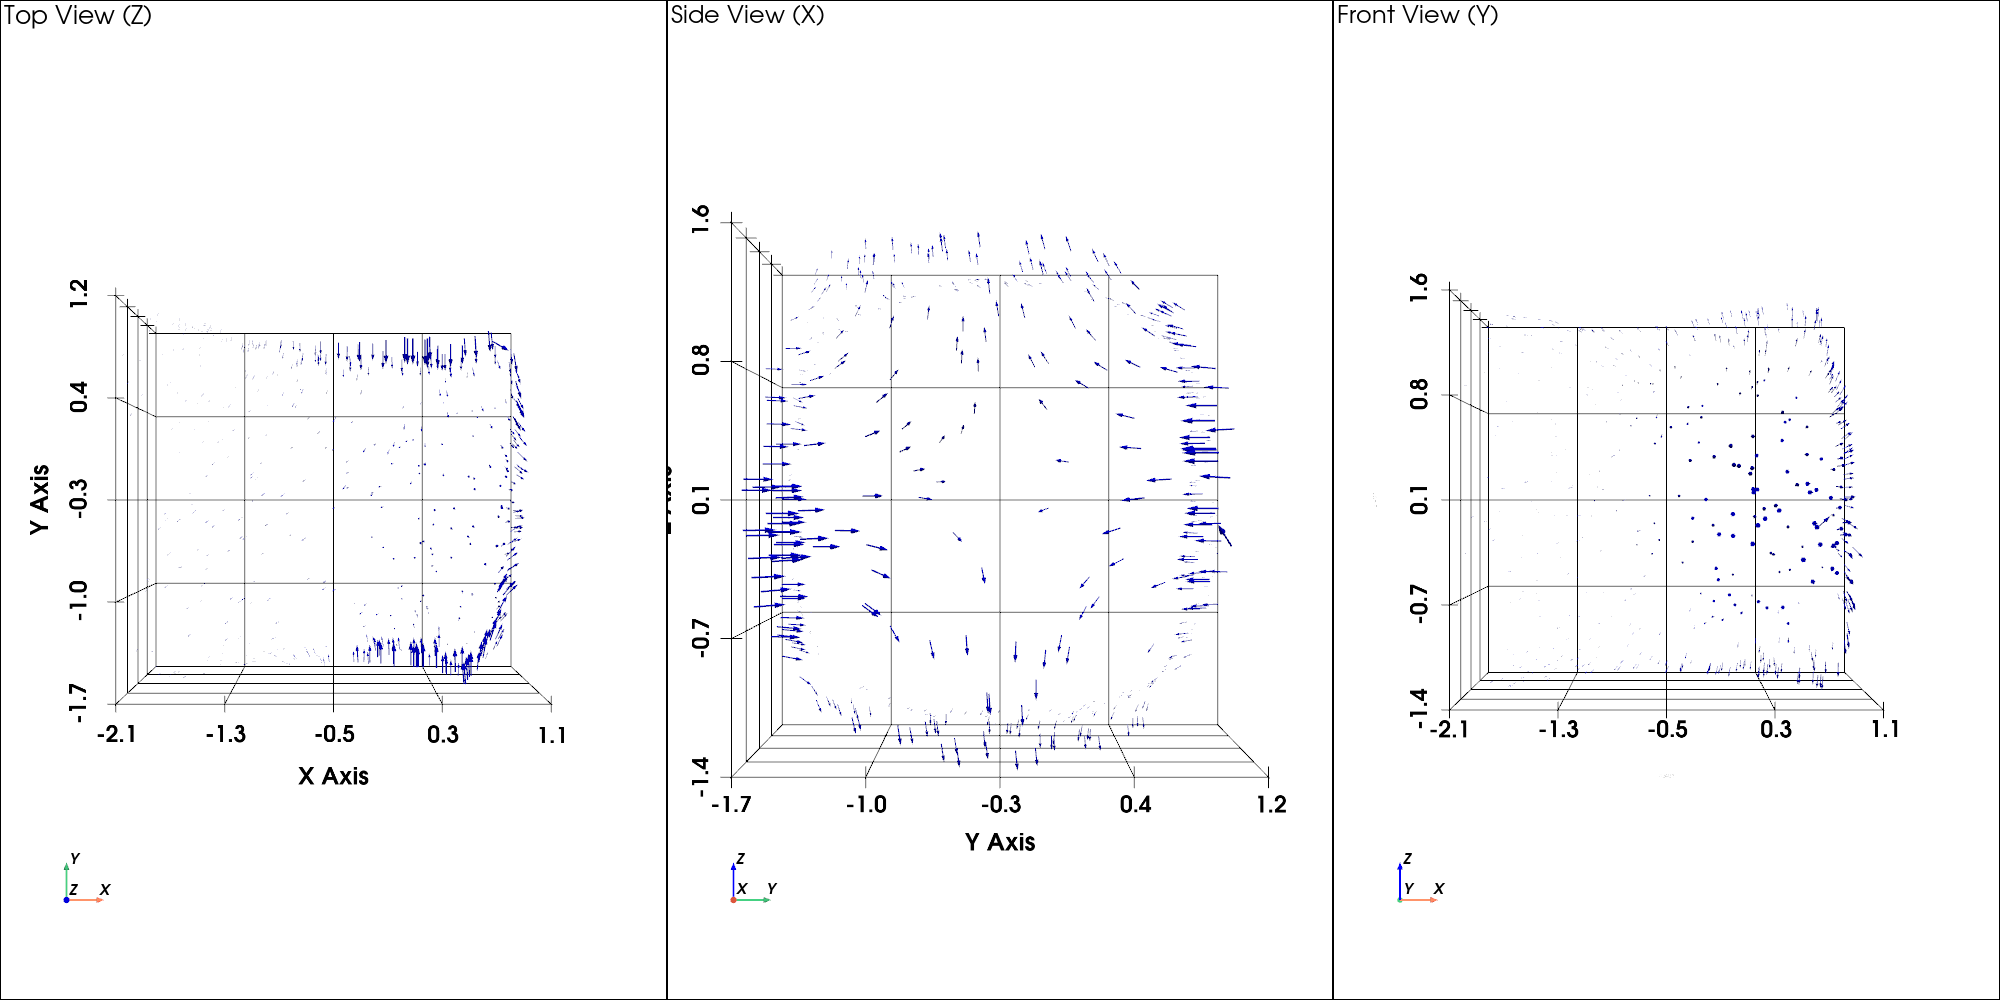

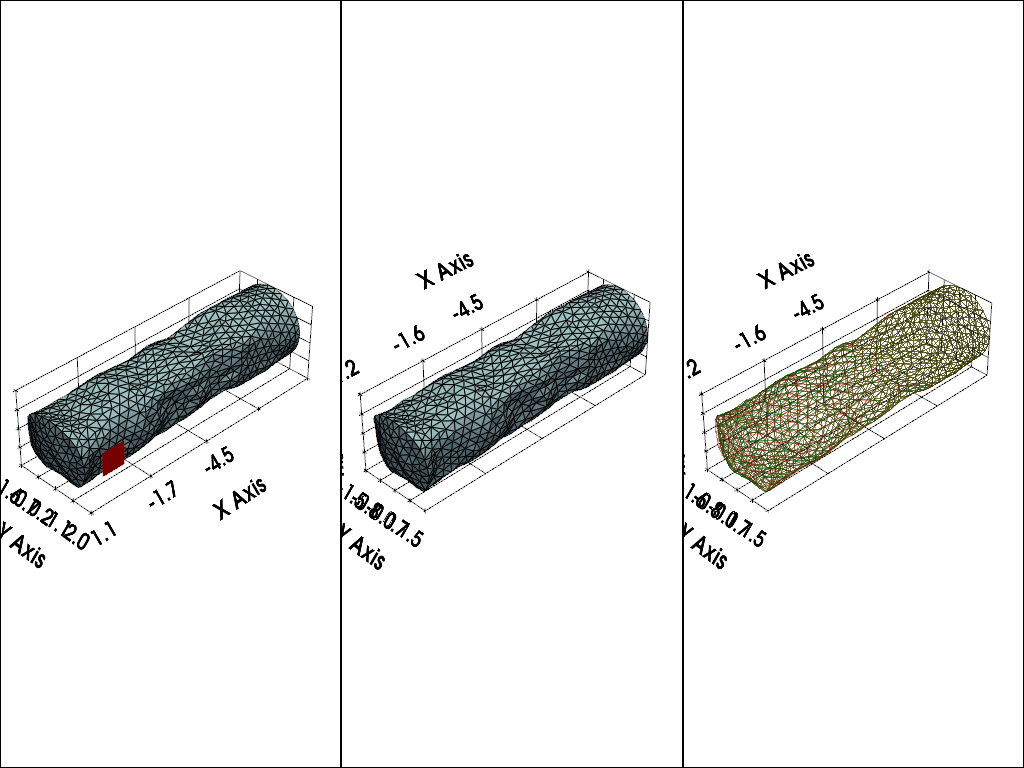

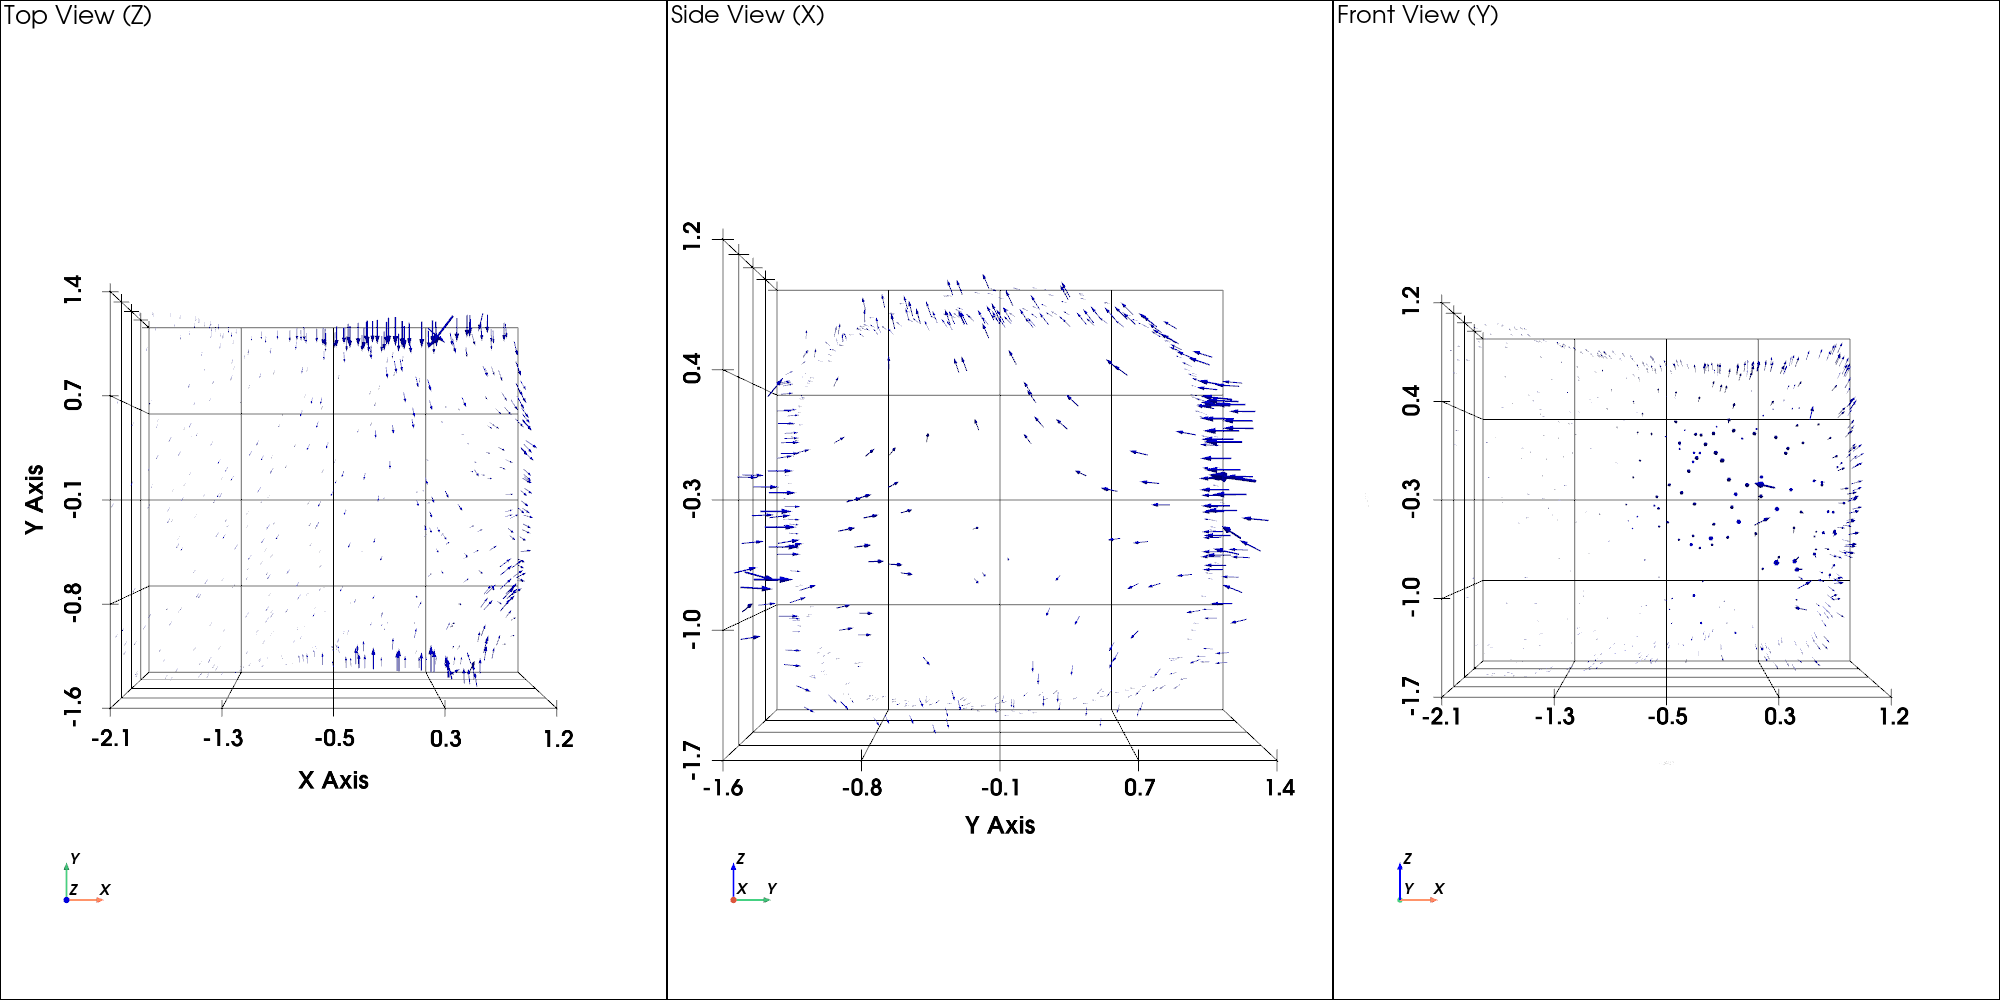

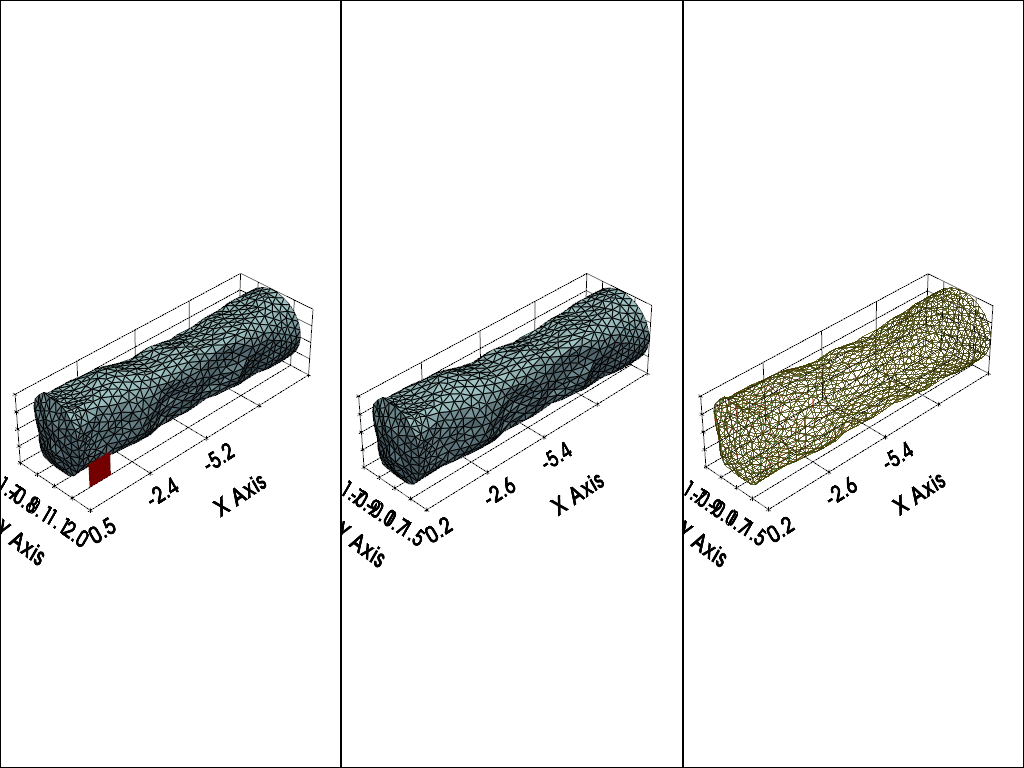

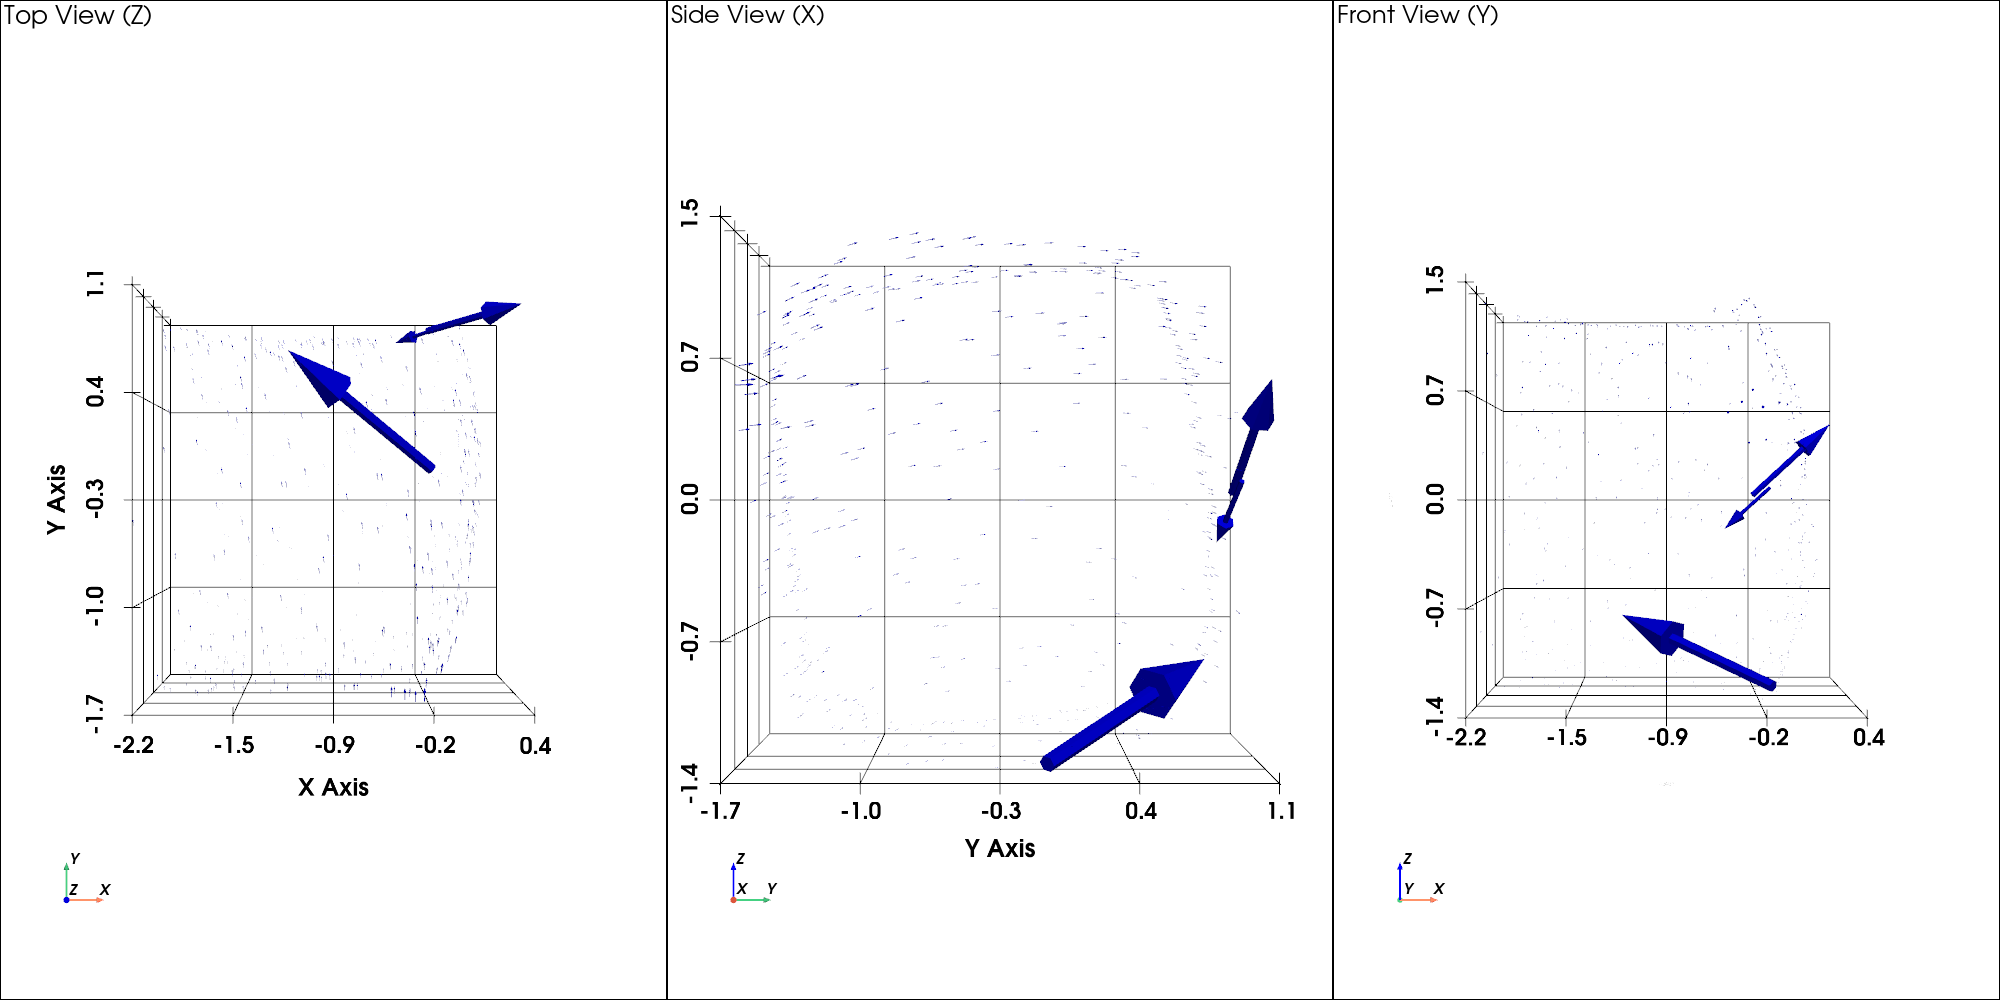

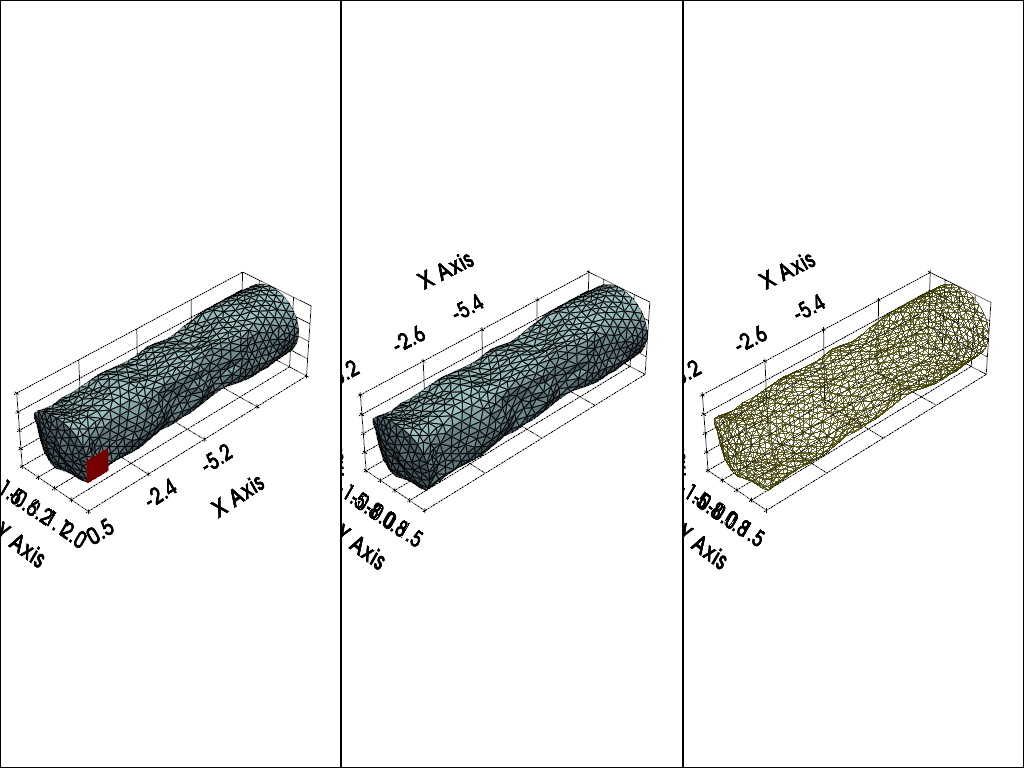

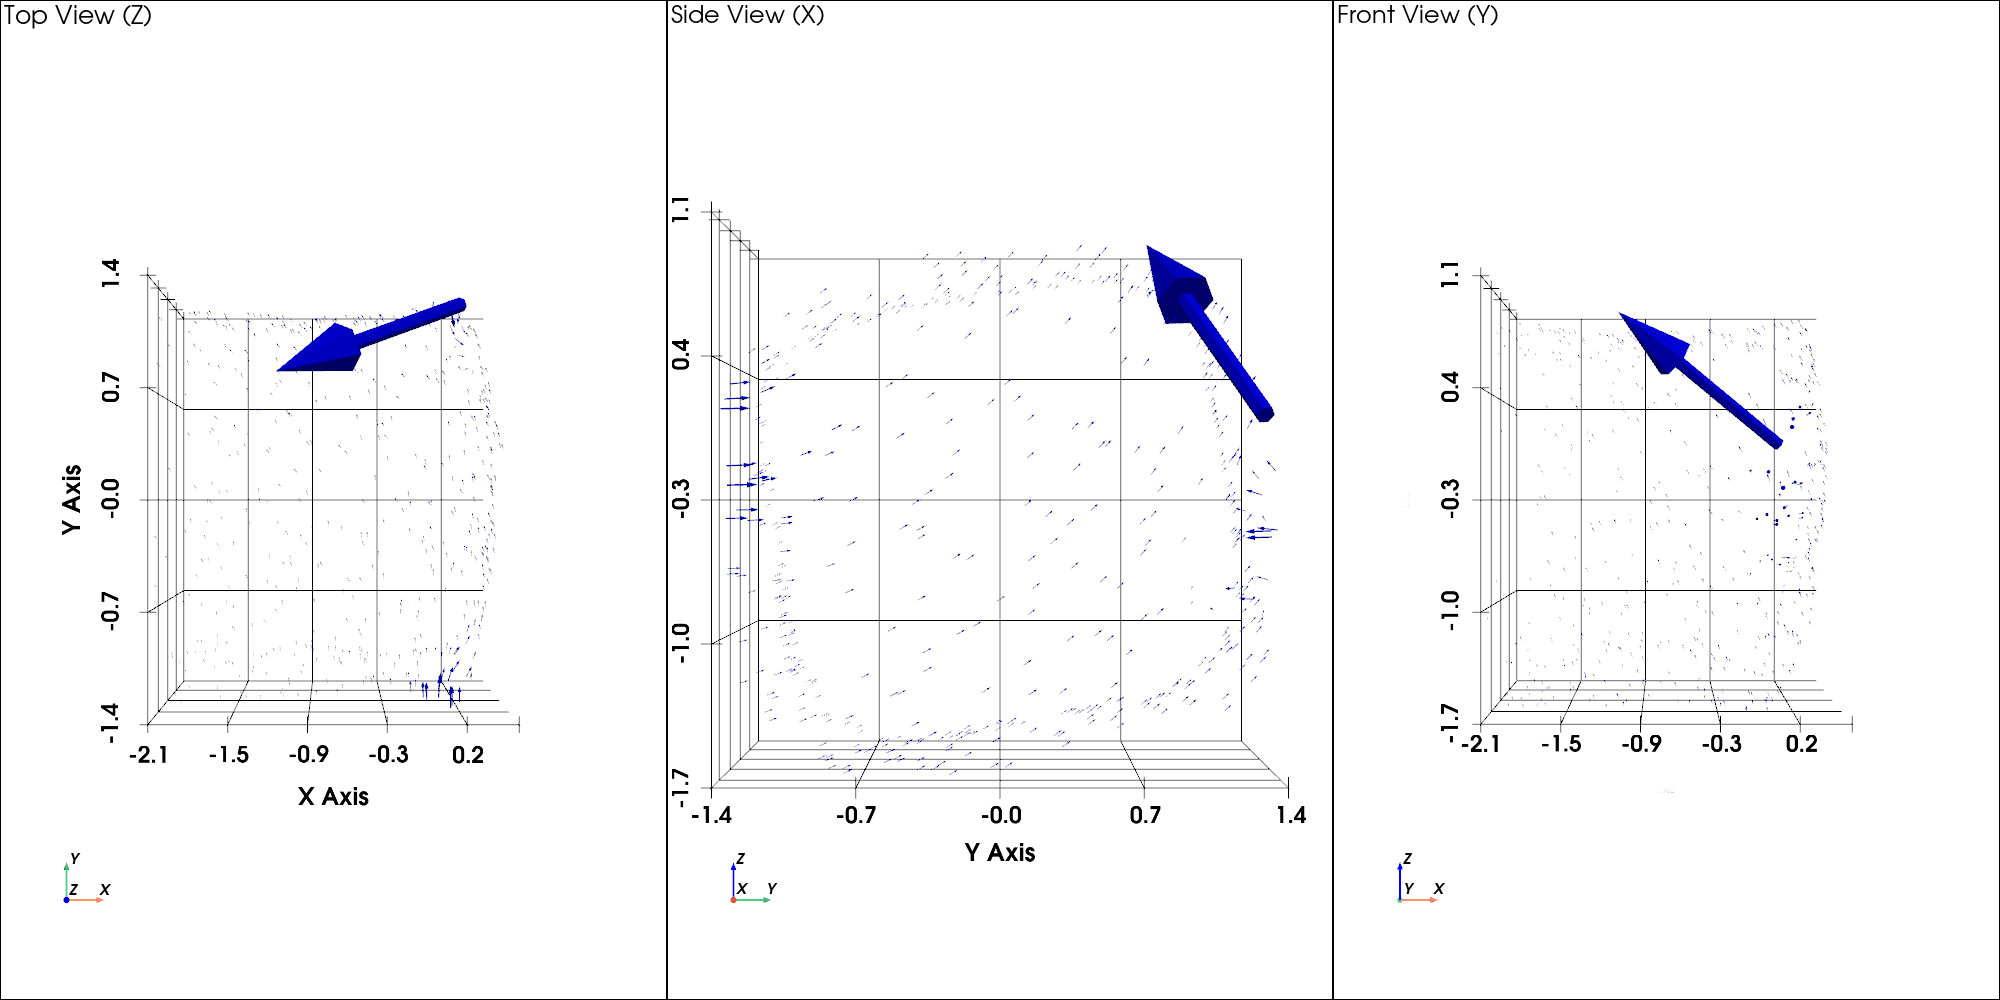

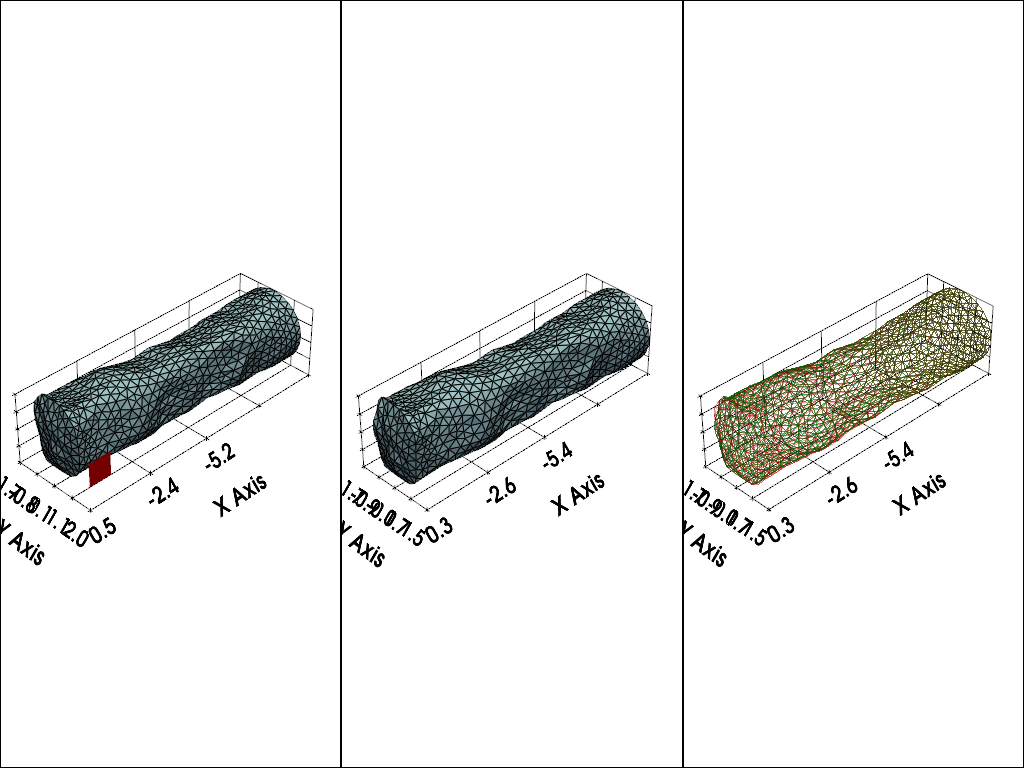

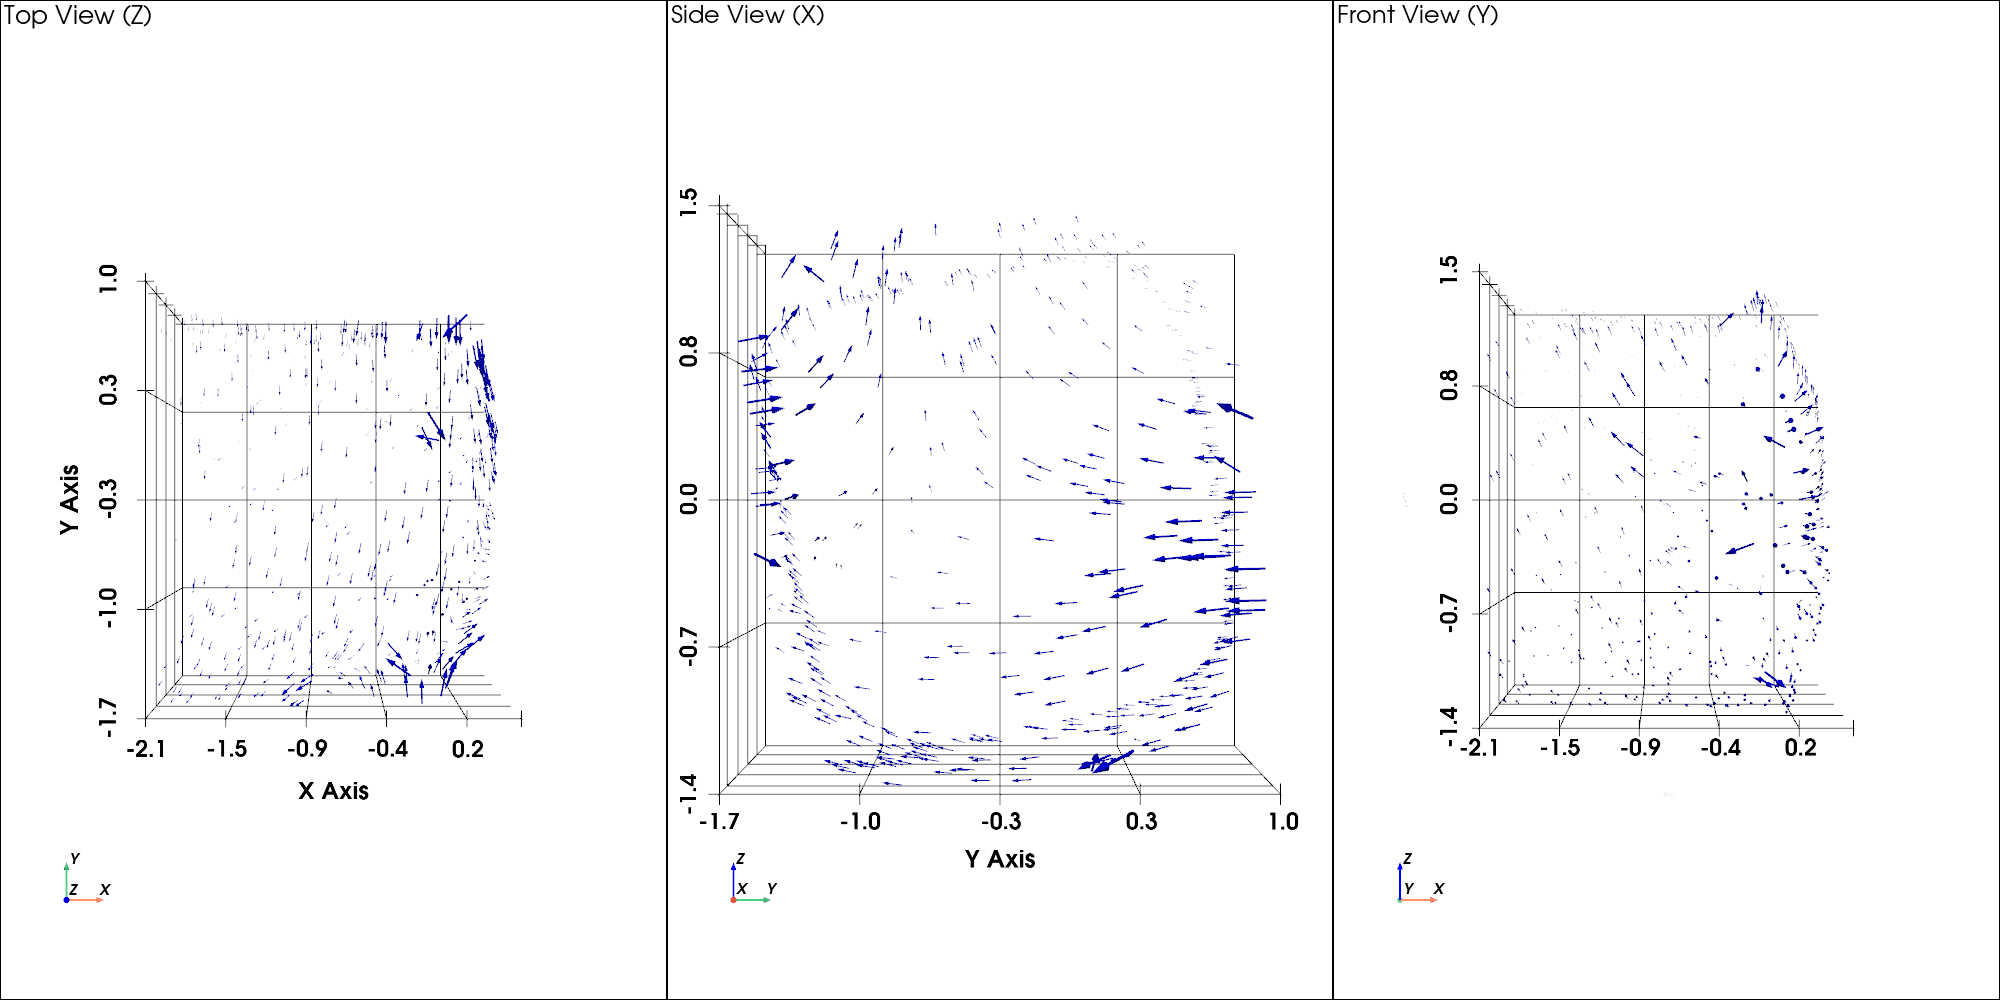

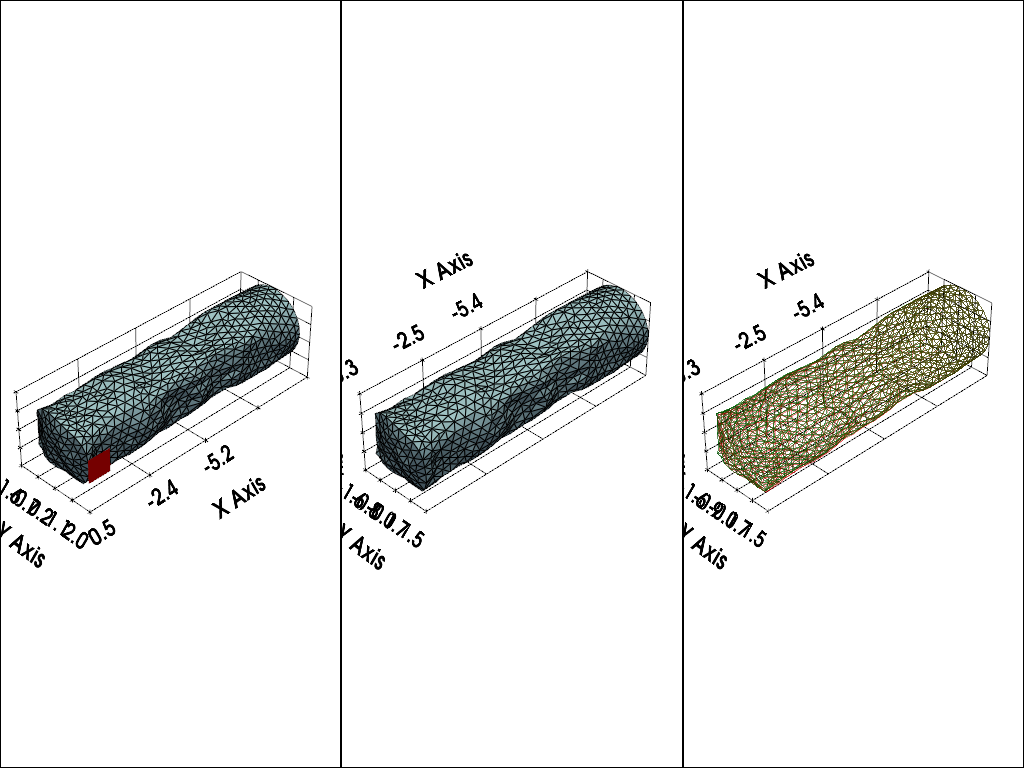

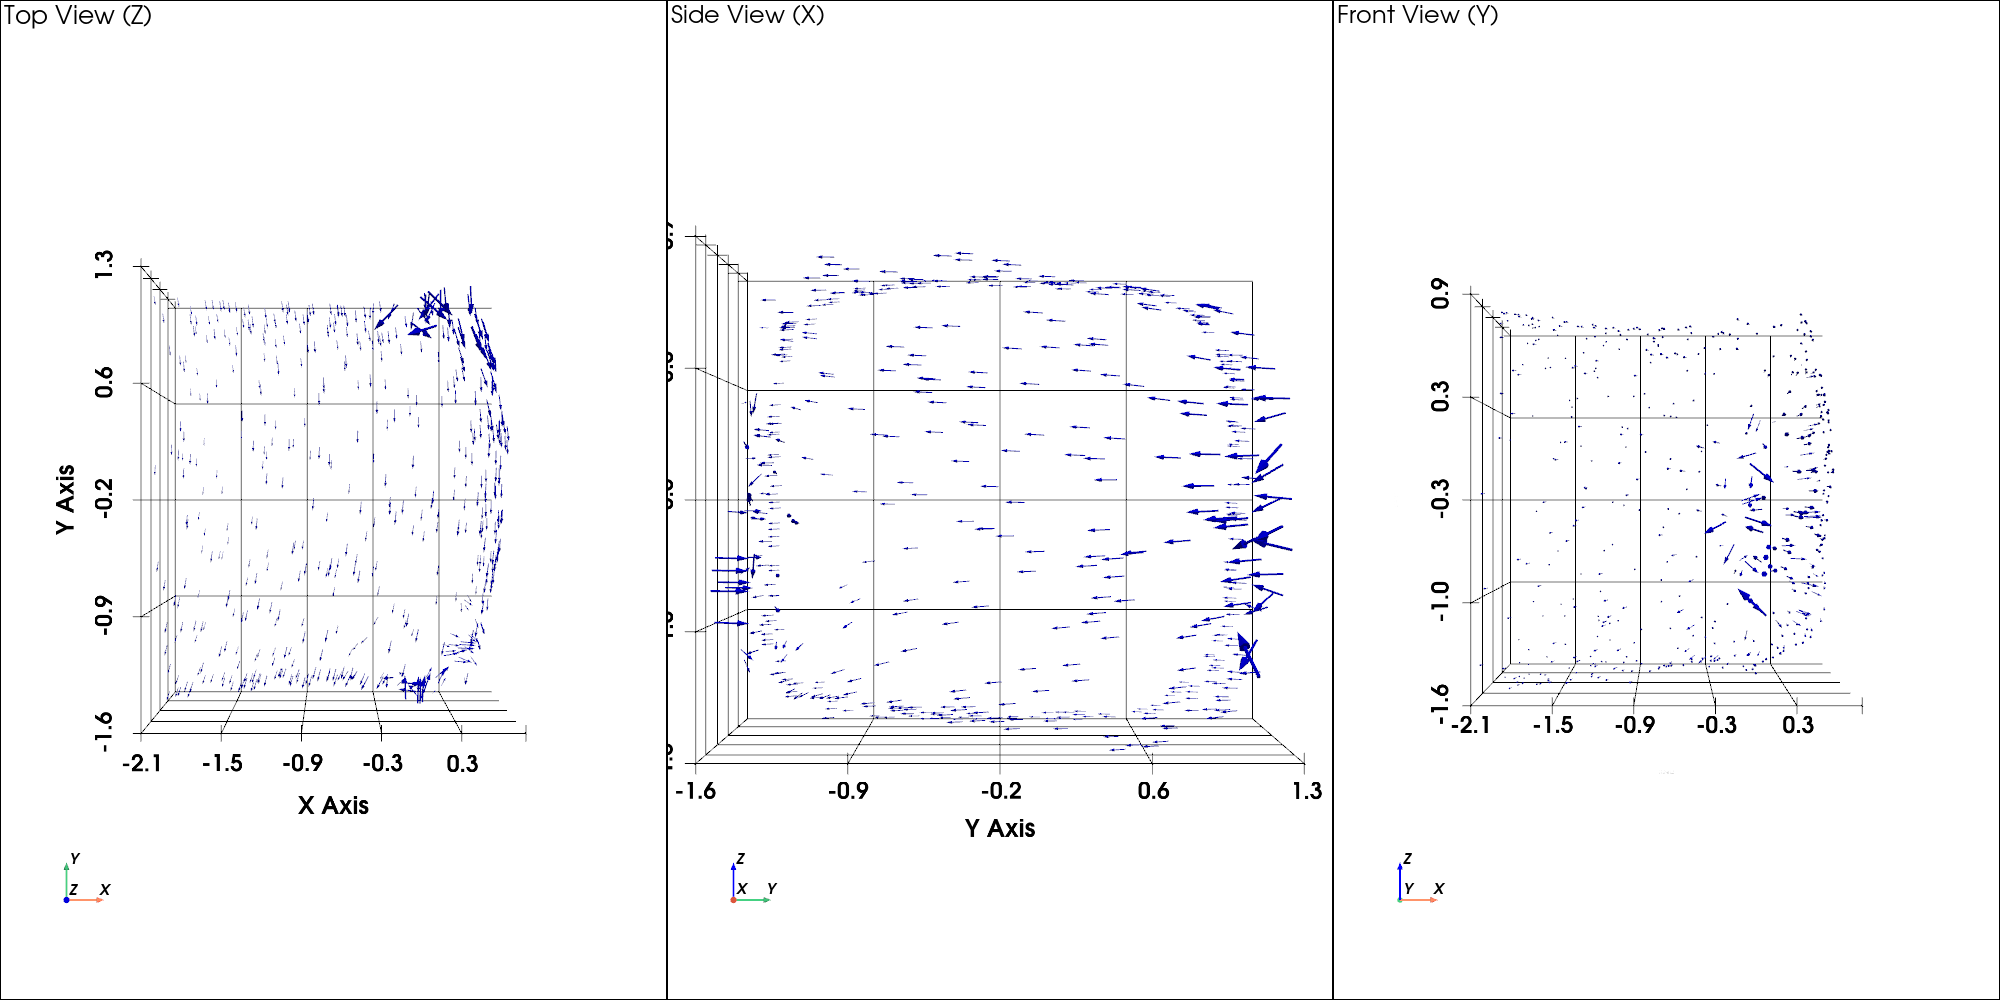

In [4]:
clear_output()

series_start_idx = 55 #65
series_end_idx = 64 #75
print(series_start_idx, series_end_idx)
# Determine global x, y, z ranges across all meshes
x_min, x_max = float('inf'), float('-inf')
y_min, y_max = float('inf'), float('-inf')
z_min, z_max = float('inf'), float('-inf')

for idx in range(series_start_idx, series_end_idx):
    for mesh in [data['meshes'][idx], data['meshes_tp1'][idx]]:
        bounds = mesh.bounds
        x_min = min(x_min, bounds[0])
        x_max = max(x_max, bounds[1])
        y_min = min(y_min, bounds[2])
        y_max = max(y_max, bounds[3])
        z_min = min(z_min, bounds[4])
        z_max = max(z_max, bounds[5])

# Playback loop
for i in range(series_start_idx, series_end_idx):
    pl = pv.Plotter(shape=(1,3))
    
    pl.subplot(0, 0)
    # data['meshes'][i].points = transform_points(data['meshes'][i].points, [0.1,0.1,0.5,1.0], translation_vector=[0,0,0])
    pl.add_mesh(data['meshes'][i], show_edges=True)
    plane = pv.Plane(center=[0,2,0],direction=[0,1,0])
    # plane.points = untransform_points(points=plane.points, quaternion=data['rotations'][i], translation_vector=[0,0,0])
    pl.add_mesh(plane, color='red')
    pl.show_grid()
    pl.isometric_view()

    pl.subplot(0, 1)
    pl.add_mesh(data['meshes_tp1'][i], show_edges=True)
    pl.show_grid()
    pl.view_xy()
    pl.isometric_view()

    pl.subplot(0, 2)
    pl.add_mesh(data['meshes'][i], show_edges=True, style='wireframe', opacity=0.2, color='red')
    pl.add_mesh(data['meshes_tp1'][i], show_edges=True, style='wireframe', opacity=0.4,color='green')
    pl.show_grid()
    pl.view_xy()
    pl.isometric_view()

    
    pl.show(interactive_update=True, auto_close=False)
    visualize_vector_diff(mesh1=None, mesh2=None,pc1=data['coords_t'][i],pc2=data['coords_tp1'][i])
    
    pl.close()

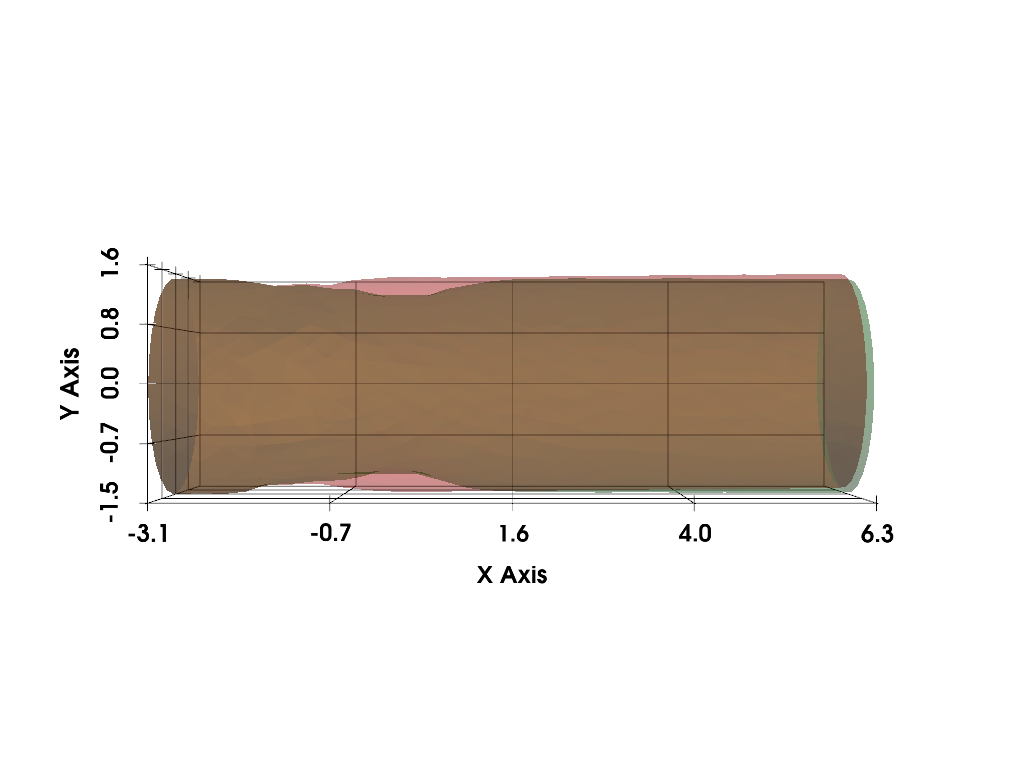

In [13]:
idx = 77
pl = pv.Plotter()
pl.add_mesh(data['meshes'][idx], opacity=0.25, color='red')
pl.show_grid()
pl.view_xy()
pl.add_mesh(data['meshes_tp1'][idx], opacity=0.25, color='green')
pl.show_grid()
pl.view_xy()
pl.show()
pl.export_html('pv.html')

In [3]:
# data  = np.load('/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/data/test_comb_FOR_large_512.npz')

c_t = data['coords_t']
c_tp1 = data['coords_tp1']
s = data['steps']
p = data['positions']
r = data['rotations']
if compute_bc_mask:
    bc_masks = data['bc_masks']
if compute_spatial_features:
    distances = data['distances_to_bc_edge']
    contact_dirs = data['contact_directions']


series_lengths = data['series_lengths'] 
series_ids = data['series_ids']

In [7]:
# deg = np.array([[quat_to_eulerxyz(quat)[0]] for quat in r])
#np.hstack((s, p[:,0].reshape(-1,1), deg))


In [15]:
print(c_t.shape), print(c_tp1.shape), print(s.shape), print(p.shape), print(r.shape)
print(series_lengths)
# print(series_ids)
# # if compute_bc_mask:
# #     print(bc_masks.shape)
# # if compute_spatial_features:
# #     print(distances.shape)
# #     print(contact_dirs.shape)

(197988, 512, 3)
(197988, 512, 3)
(197988, 1)
(197988, 3)
(197988, 4)
[11, 53, 10, 51, 83, 79, 137, 7, 49, 71, 91, 125, 9, 55, 71, 107, 143, 9, 65, 65, 87, 167, 12, 53, 71, 87, 149, 11, 55, 68, 103, 137, 11, 47, 65, 87, 167, 10, 51, 62, 83, 113, 12, 59, 74, 91, 149, 8, 45, 80, 91, 143, 12, 49, 77, 99, 149, 9, 45, 68, 91, 143, 9, 9, 53, 83, 79, 137, 9, 47, 71, 83, 125, 9, 49, 77, 103, 137, 8, 45, 71, 95, 131, 11, 53, 80, 99, 161, 11, 59, 80, 83, 137, 11, 57, 83, 99, 131, 9, 51, 83, 91, 137, 8, 37, 68, 75, 125, 9, 53, 71, 99, 143, 12, 69, 68, 95, 137, 8, 55, 71, 83, 155, 11, 59, 68, 95, 179, 10, 59, 68, 99, 143, 8, 41, 80, 87, 137, 8, 63, 74, 91, 155, 12, 53, 68, 83, 179, 12, 57, 68, 87, 149, 10, 57, 59, 79, 143, 10, 43, 77, 99, 149, 11, 49, 74, 87, 137, 10, 45, 83, 95, 137, 11, 49, 77, 75, 125, 9, 51, 62, 95, 161, 5, 9, 57, 65, 95, 167, 8, 49, 62, 79, 155, 9, 47, 59, 87, 131, 12, 67, 71, 83, 131, 10, 49, 77, 75, 149, 11, 57, 68, 107, 143, 9, 45, 74, 87, 131, 10, 39, 68, 91, 161, 11, 47,

In [1]:
# visuali3ze_point_cloud(c_t[25],a=-p[25], point_size=5)
idx = 1
print(s[idx])
print(p[idx])
print(r[idx])

compare_scatters(pc1=c_t[idx], pc2=c_tp1[idx])
visualize_vector_diff(mesh1=None, mesh2=None, 
                      pc1=c_t[idx],
                      pc2=c_tp1[idx])
# visualize_bc_features(
#     c_t[idx], 
#     bc_masks[idx], 
#     distances[idx],
#     title_prefix="Sample "
# )
# delta_x = np.abs(c_t[idx][:,0] - c_tp1[idx][:,0])
# delta_z = np.abs(c_t[idx][:,2] - c_tp1[idx][:,2])

# deltas_vs_x(pc=c_t[idx], delta_x=delta_x, delta_z=delta_z, title_prefix="")



NameError: name 's' is not defined

In [10]:
# np.savez('./test_comb_FOR.npz', coords_t=c_t, coords_tp1=c_tp1, steps=s, series_lengths=np.array(series_lengths))

In [17]:
np.savez('./test_comb_FOR_large_512.npz', coords_t=c_t, coords_tp1=c_tp1, steps=s, positions=p, rotations=r, series_lengths=np.array(series_lengths))